In [21]:
# !pip install matplotlib

In [22]:
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import numpy as np
from scipy.stats import norm
from scipy.optimize import curve_fit

In [23]:
def comma_to_float(valstr):
    return float(valstr.decode("utf-8"))

In [24]:
t,x,y = np.loadtxt("position_data.txt", delimiter=",", dtype="float",
                   unpack=True)

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_8374/2068721524.py:2: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('x / '+' $\mu$'+'m')
/tmp/ipykernel_8374/2068721524.py:3: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('y / '+' $\mu$'+'m')


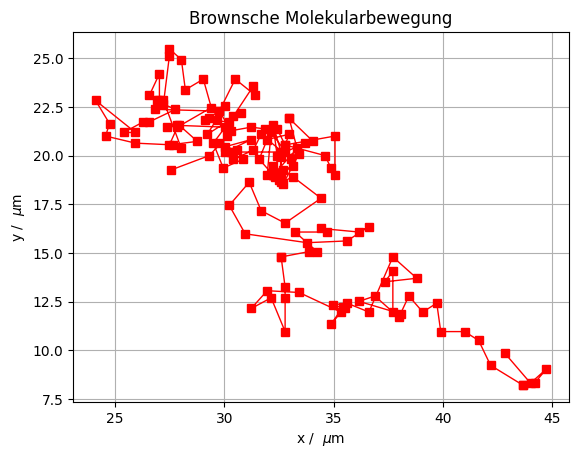

In [25]:
plt.plot(x, y, marker='s', color='red', linewidth=1)
plt.xlabel('x / '+' $\mu$'+'m')
plt.ylabel('y / '+' $\mu$'+'m')
plt.title('Brownsche Molekularbewegung')
plt.grid()

plt.savefig('Test1.pdf')
plt.show()

In [26]:
dt=np.array([])
dx=np.array([])
dy=np.array([])
i=0
while i < len(t)-1:
    dt=np.append(dt,t[i+1]-t[i])
    dx=np.append(dx,x[i+1]-x[i])
    dy=np.append(dy,y[i+1]-y[i])
    i = i + 1
r_squared=dx**2+dy**2

In [27]:
r_squared_mean=np.mean(r_squared)
print("r_squared_mean= {} m^2".format(r_squared_mean))
r_squared_mean_std=np.std(r_squared)/np.sqrt(len(r_squared))
print("r_squared_mean_std= {} m^2".format(r_squared_mean_std))
dt_mean=np.mean(dt)
print("dt_mean= {}s".format(dt_mean))
#dt_mean_std = np.std(dt error)/np.sqrt(len(dt))
#print("dt_mean_std = {}s".format(dt_mean_std)) # Vernachlässigbar

r_squared_mean= 1.754955840902013 m^2
r_squared_mean_std= 0.1441045288746259 m^2
dt_mean= 1.0s


Mittelwert: 0.01961234899328859
Standardabweichung 0.9365325815036932


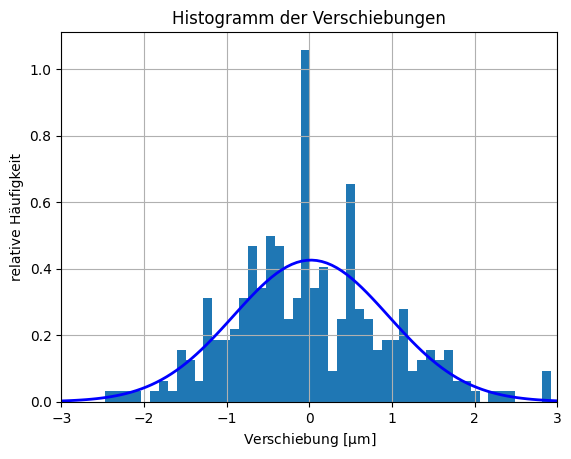

In [28]:
all_data=np.append(dx,dy)
plt.hist(all_data, density=True, bins = 50)

mu=np.mean(all_data)
sigma=np.std(all_data)
gauss = norm.pdf(np.linspace(-3,3,num=100), mu, sigma)

plt.plot(np.linspace(-3,3,num=100), gauss, 'b-', linewidth=2)
plt.xlim(-3,3)
print('Mittelwert:', mu)
print("Standardabweichung", sigma)
plt.title("Histogramm der Verschiebungen")
plt.xlabel(r'Verschiebung [$\mathrm{\mu}$m]')
plt.ylabel('relative Häufigkeit')
plt.grid()
plt.savefig('Test2.pdf')
plt.show()

a: (1.737258434256792 +- 0.0064034187874342985) b: (4.012562466683262 +- 0.548081689200882)


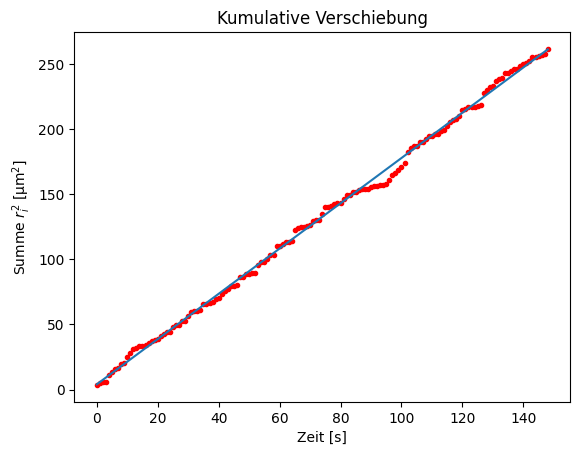

In [29]:
r_kumm=np.cumsum(r_squared)

def linear(x,a,b):
    return a*x+b

popt, pcov = curve_fit(linear, t[:-1], r_kumm)
print(f"a: ({popt[0]} +- {np.sqrt(pcov[0,0])})", f"b: ({popt[1]} +- {np.sqrt(pcov[1,1])})")
plt.plot(t[:-1], r_kumm, marker='.', color='red', linewidth=0)
plt.plot(t[:-1], linear(t[:-1],*popt))
plt.xlabel('Zeit [s]')
plt.ylabel(r'Summe $r_i^2$ [$\mathrm{\mu m^2}$]')
plt.title('Kumulative Verschiebung')
#plt.legend()
plt.savefig('Test3.pdf')
plt.show()

In [30]:
a = 377.5e-9  #r=d/2
da = 15e-9 
T = 295.75
dT = 1
eta  = 9.45*10**(-4)
deta  = 0.1  * 10**(-4)
m  = popt[0] * 10**(-12)
dm = np.sqrt(pcov[0][0])* 10**(-12)

dict = {"Radius (da/a)": da/a,
       "Temperatur (dT/T)": dT/T,
       "Viskosität (deta/eta)": deta/eta,
       "Steigung m (dm/m)": dm/m,
       "m. Verschiebungsquadrat (dr^2/r^2)":r_squared_mean_std/r_squared_mean }
"""
df = pd.DataFrame(data=dict)
pd.display()
"""
#print("Fehleranteile:",da/a, dT/T, deta/eta, dm/m, r_squared_mean_std/r_squared_mean) #dt_mean/t
# -> Vernachlässigung aller Fehler bis auf den Fehler des Radiuses

# Berechnung der Boltzmannkonstante aus den Rohdaten(r^2, t) 
kB_r =  6 * np.pi*eta * a * r_squared_mean*1e-12/(4* T*dt_mean) 
dkB_r = np.sqrt((kB_r/a * da)**2 + (kB_r/(r_squared_mean*1e-12) * r_squared_mean_std*1e-12)**2)

# Berechnung der Boltzmannkonstante aus der Approximationsgeradensteigung
kB_m =  6 * np.pi*eta * a/(4* T) * m
dkB_m =  6 * np.pi*eta * m/(4* T) * da

# Berechnung der Diffusionskoeffizient aus der Approximationsgeradensteigung
D_m = m/4
dD_m = dm/4

# Berechnung
D_r = r_squared_mean/(4*dt_mean)
dD_r = r_squared_mean_std/(4*dt_mean)

# Wertevergleiche 
kB_l =  1.38064852e-23 # Literaturwert
sig_kb1 = np.abs(kB_l - kB_r)/dkB_r
sig_kb2 = np.abs(kB_l - kB_m)/dkB_m
sig_kb3 = np.abs(kB_r - kB_m)/np.sqrt(dkB_r**2 + dkB_m**2)

print("---------")
print("Boltzmannkonstante kB (Steigung): kB = ({} ± {}) J/K ".format(kB_m,dkB_m))
print("Boltzmannkonstante kB (Rohdaten): kB = ({} ± {}) J/K ".format(kB_r,dkB_r))

print("Abweichung (Literaturwert - Steigung): {}σ".format(sig_kb2))
print("Werteabweichung (Literaturwert - Rohdaten): {}σ".format(sig_kb1))
print("Werteabweichung (Steigung - Rohdaten): {}σ".format(sig_kb3))

# Berechnung der Diffusionskoeffizient
sig_D = np.abs(D_r - D_m)/np.sqrt(dD_r**2 + dD_m**2)

print("---------")
print("Diffusionskoeffizient D (Steigung): D = ({} ± {}) m^2/s ".format(D_m,dD_m))
print("Diffusionskeffizient D (Rohdaten): D = ({} ± {}) m^2/s ".format(D_r,dD_r))
print("Werteabweichung: {}σ".format(sig_D))

---------
Boltzmannkonstante kB (Steigung): kB = (9.874828726129295e-24 ± 3.9237730037599842e-25) J/K 
Boltzmannkonstante kB (Rohdaten): kB = (9.975423350436289e-24 ± 9.099755878348067e-25) J/K 
Abweichung (Literaturwert - Steigung): 10.020091554998634σ
Werteabweichung (Literaturwert - Rohdaten): 4.210071018146023σ
Werteabweichung (Steigung - Rohdaten): 0.10151158246657513σ
---------
Diffusionskoeffizient D (Steigung): D = (4.34314608564198e-13 ± 1.6008546968585745e-15) m^2/s 
Diffusionskeffizient D (Rohdaten): D = (0.43873896022550324 ± 0.03602613221865648) m^2/s 
Werteabweichung: 12.178353134391255σ
